# Delayed Market Reaction Analysis
**Analyzing 8-K Filings for Delayed Market Responses**

## Delayed Reaction Definition
A filing exhibits a "delayed reaction" if:
1. **Weak immediate response**: |R_short| < 1% (days 0-1)
2. **Strong delayed drift**: |R_long| > 3% (days 5-20)  
3. **Same direction**: Both positive or both negative

---

In [65]:
# Install required packages (uncomment if needed)
# !pip install yfinance

In [66]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
warnings.filterwarnings("ignore")

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries loaded")

✓ Libraries loaded


## Configuration

In [67]:
# Study period
START_DATE = "2023-01-01"
END_DATE = "2023-12-31"
BENCHMARK = "^GSPC"  # S&P 500

# Download extra days for forward-looking windows
FETCH_START = "2022-12-15"
FETCH_END = "2024-01-31"

# Delayed reaction thresholds
SHORT_THRESHOLD = 0.01  # 1% - max immediate reaction
LONG_THRESHOLD = 0.03   # 3% - min delayed drift

# Filing time assumption (conservative: assume after-hours)
DEFAULT_FILING_TIME = "17:00"  # 5 PM ET

print(f"Study period: {START_DATE} to {END_DATE}")
print(f"Thresholds: R_short < {SHORT_THRESHOLD*100}%, R_long > {LONG_THRESHOLD*100}%")

Study period: 2023-01-01 to 2023-12-31
Thresholds: R_short < 1.0%, R_long > 3.0%


## Step 1: Load Filings Data

In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
# Load your filings CSV file
# UPDATE THIS PATH to point to your filings_raw.csv file
FILINGS_PATH = "/content/drive/MyDrive/Big Data Trends Market Team 10/data/filings_raw.csv"

filings = pd.read_csv(FILINGS_PATH)

print(f"Loaded {len(filings)} filings")
print(f"Tickers: {filings['ticker'].nunique()}")
print(f"Date range: {filings['filed_date'].min()} → {filings['filed_date'].max()}")
print(f"\nForm types: {filings['form_type'].unique()}")
print(f"\nFirst few filings:")
filings[['ticker', 'filed_date', 'form_type', 'company_name']].head(10)

Loaded 474 filings
Tickers: 42
Date range: 2023-01-03 → 2023-12-29

Form types: ['8-K']

First few filings:


,ticker,filed_date,form_type,company_name
0,AAPL,2023-11-02,8-K,Apple Inc.
1,AAPL,2023-08-03,8-K,Apple Inc.
2,AAPL,2023-05-10,8-K,Apple Inc.
3,AAPL,2023-05-04,8-K,Apple Inc.
4,AAPL,2023-03-10,8-K,Apple Inc.
5,AAPL,2023-02-02,8-K,Apple Inc.
6,MSFT,2023-12-08,8-K,MICROSOFT CORP
7,MSFT,2023-11-06,8-K,MICROSOFT CORP
8,MSFT,2023-10-30,8-K,MICROSOFT CORP
9,MSFT,2023-10-24,8-K,MICROSOFT CORP


In [70]:
# Get unique tickers
TICKERS = sorted(filings['ticker'].unique())
print(f"Tickers to analyze ({len(TICKERS)}): {', '.join(TICKERS[:10])}...")

Tickers to analyze (42): AAPL, ABBV, ADBE, AMZN, AXP, BA, CAT, CMCSA, COP, COST...


## Step 2: Download Market Data

In [71]:
print("Downloading price data from Yahoo Finance...")
print("This may take 1-2 minutes...\n")

all_tickers = TICKERS + [BENCHMARK]

raw = yf.download(
    all_tickers,
    start=FETCH_START,
    end=FETCH_END,
    auto_adjust=True,
    progress=True
)

# Extract adjusted close prices
if isinstance(raw.columns, pd.MultiIndex):
    prices_all = raw["Close"]
else:
    prices_all = raw[["Close"]]

benchmark_raw = prices_all[BENCHMARK].rename("benchmark")
prices_raw = prices_all[TICKERS]

print(f"\n✓ Downloaded {prices_raw.shape[0]} days × {prices_raw.shape[1]} tickers")

This may take 1-2 minutes...



[*********************100%***********************]  43 of 43 completed


✓ Downloaded 281 days × 42 tickers


## Step 3: Clean and Prepare Data

In [72]:
# Forward-fill short gaps (max 2 days)
prices_clean = prices_raw.ffill(limit=2)
benchmark_clean = benchmark_raw.ffill(limit=2)

# Drop tickers with >5% missing data
threshold = 0.05 * len(prices_clean)
still_miss = prices_clean.isna().sum()
bad_tickers = still_miss[still_miss > threshold].index.tolist()

if bad_tickers:
    print(f"⚠ Dropping tickers with >5% missing: {bad_tickers}")
    prices_clean = prices_clean.drop(columns=bad_tickers)
    TICKERS = [t for t in TICKERS if t not in bad_tickers]

# Align to benchmark trading days
valid_idx = benchmark_clean.dropna().index
prices_clean = prices_clean.loc[valid_idx]
benchmark_clean = benchmark_clean.loc[valid_idx]

print(f"✓ Clean data: {prices_clean.shape[0]} days × {prices_clean.shape[1]} tickers")

✓ Clean data: 281 days × 42 tickers


In [73]:
# Build trading calendar
calendar_study = prices_clean.loc[START_DATE:END_DATE].index
print(f"✓ Study period: {len(calendar_study)} days ({calendar_study[0].date()} → {calendar_study[-1].date()})")

# Extended calendar - for event window calculations (includes early 2024 for R_long)
calendar_extended = prices_clean.loc[FETCH_START:FETCH_END].index
print(f"✓ Extended calendar: {len(calendar_extended)} days (for R_long window calculations)")

✓ Study period: 250 days (2023-01-03 → 2023-12-29)
✓ Extended calendar: 281 days (for R_long window calculations)


## Step 4: Calculate Returns

In [80]:
# Calculate daily returns
stock_returns_all = prices_clean.pct_change()
benchmark_returns_all = benchmark_clean.pct_change()
abnormal_returns_full = stock_returns_all.sub(benchmark_returns_all, axis=0)

# Restrict to study period
stock_returns = stock_returns_all.loc[calendar_study]
benchmark_returns = benchmark_returns_all.loc[calendar_study]

# Calculate abnormal returns (stock - market)
abnormal_returns = stock_returns.sub(benchmark_returns, axis=0)

print(f"  Stock returns: {stock_returns.shape}")
print(f"  Abnormal returns: {abnormal_returns.shape}")

# Quick check
stock_returns.head(5)

  Stock returns: (250, 42)
  Abnormal returns: (250, 42)


Ticker,AAPL,ABBV,ADBE,AMZN,AXP,BA,CAT,CMCSA,COP,COST,...,QCOM,SBUX,SLB,T,TSLA,UNH,UNP,VZ,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-03,-0.037405,0.004764,0.001159,0.021667,-0.004264,0.025723,-0.002839,0.025072,-0.041356,-0.007054,...,-0.024923,0.016432,-0.036663,0.017925,-0.122422,-0.021766,0.002463,0.018274,0.012765,-0.034361
2023-01-04,0.010314,0.008067,0.013327,-0.007924,0.023246,0.042223,0.010382,0.028676,0.001945,0.007236,...,0.040392,0.036001,0.003884,0.021345,0.051249,-0.027264,0.007997,0.025175,0.001114,0.002910
2023-01-05,-0.010605,-0.001222,-0.037990,-0.023726,-0.023930,0.006629,-0.004475,0.010659,0.030263,-0.013952,...,-0.019098,-0.000287,0.018762,0.003657,-0.029039,-0.028821,-0.029440,0.013859,-0.003409,0.022374
2023-01-06,0.036794,0.018717,0.013123,0.035611,0.025541,0.039075,0.035708,0.024608,0.012503,0.072592,...,0.054296,0.021641,0.034745,0.016658,0.024651,0.000082,0.043973,0.011750,0.024499,0.012087
2023-01-09,0.004089,-0.029361,0.027739,0.014870,0.001532,-0.020798,-0.009001,-0.008973,-0.007359,-0.008533,...,-0.006329,-0.018277,0.020918,-0.011012,0.059349,0.000122,-0.002594,-0.004020,-0.012468,-0.018637


In [75]:
benchmark_returns.head(5)

,benchmark
Date,
2023-01-03,-0.004001
2023-01-04,0.007539
2023-01-05,-0.011646
2023-01-06,0.022841
2023-01-09,-0.000768


In [76]:
abnormal_returns.head(5)

Ticker,AAPL,ABBV,ADBE,AMZN,AXP,BA,CAT,CMCSA,COP,COST,...,QCOM,SBUX,SLB,T,TSLA,UNH,UNP,VZ,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-03,-0.033404,0.008765,0.005159,0.025667,-0.000263,0.029724,0.001162,0.029073,-0.037355,-0.003053,...,-0.020922,0.020432,-0.032662,0.021926,-0.118422,-0.017766,0.006464,0.022275,0.016766,-0.030360
2023-01-04,0.002775,0.000529,0.005788,-0.015463,0.015707,0.034684,0.002843,0.021137,-0.005594,-0.000303,...,0.032853,0.028462,-0.003655,0.013806,0.043710,-0.034803,0.000458,0.017636,-0.006425,-0.004629
2023-01-05,0.001041,0.010424,-0.026344,-0.012080,-0.012284,0.018275,0.007171,0.022304,0.041908,-0.002307,...,-0.007452,0.011358,0.030407,0.015303,-0.017394,-0.017175,-0.017794,0.025504,0.008237,0.034020
2023-01-06,0.013953,-0.004124,-0.009718,0.012770,0.002700,0.016234,0.012868,0.001767,-0.010337,0.049751,...,0.031455,-0.001200,0.011904,-0.006183,0.001810,-0.022759,0.021132,-0.011091,0.001658,-0.010754
2023-01-09,0.004857,-0.028593,0.028506,0.015638,0.002299,-0.020030,-0.008234,-0.008206,-0.006591,-0.007765,...,-0.005561,-0.017510,0.021685,-0.010244,0.060117,0.000890,-0.001826,-0.003253,-0.011700,-0.017870


## Step 5: Define Event Analysis Functions

In [77]:
def get_event_day0(filing_date: str, filing_time: str, calendar: pd.DatetimeIndex):
    """
    Convert filing timestamp to Day 0 (first trading day market can react).

    Rule:
    - Filed before 4 PM ET on trading day → same day
    - Filed after 4 PM ET or non-trading day → next trading day
    """
    MARKET_CLOSE = 16  # 4 PM ET

    dt = pd.Timestamp(f"{filing_date} {filing_time}")
    date = dt.date()
    hour = dt.hour
    cal_dates = calendar.normalize()

    # On trading day before close → same day
    if pd.Timestamp(date) in cal_dates and hour < MARKET_CLOSE:
        return pd.Timestamp(date)

    # Otherwise → next trading day
    future = cal_dates[cal_dates > pd.Timestamp(date)]
    return future[0] if len(future) > 0 else None

print("✓ get_event_day0() defined")

✓ get_event_day0() defined


In [78]:
def compute_event_windows(ticker: str, day0: pd.Timestamp,
                         abnormal_returns: pd.DataFrame,
                         calendar: pd.DatetimeIndex,
                         short_threshold: float = SHORT_THRESHOLD,
                         long_threshold: float = LONG_THRESHOLD):
    """
    Compute Cumulative Abnormal Returns (CAR) for event windows.

    Returns:
        dict with R_short (0-1), R_long (5-20), and delayed_reaction flag
    """
    cal_dates = calendar.normalize()
    day0_norm = day0.normalize()

    if day0_norm not in cal_dates:
        return None

    idx = cal_dates.get_loc(day0_norm)

    # Helper to compute CAR (sum of abnormal returns)
    def _car(start_offset: int, end_offset: int):
        s = idx + start_offset
        e = idx + end_offset + 1
        if e > len(cal_dates):
            return None
        window_dates = cal_dates[s:e]
        if ticker not in abnormal_returns.columns:
            return None
        vals = abnormal_returns.loc[window_dates, ticker].dropna()
        return float(vals.sum())

    r_short = _car(0, 1)   # Days 0-1
    r_long = _car(5, 20)   # Days 5-20

    # Delayed reaction flag
    delayed = None
    if r_short is not None and r_long is not None:
        same_dir = (r_short * r_long) > 0
        delayed = (
            (abs(r_short) < short_threshold) and
            (abs(r_long) > long_threshold) and
            same_dir
        )

    return {
        'ticker': ticker,
        'day0': day0_norm.date(),
        'R_short_0_1': round(r_short, 5) if r_short is not None else None,
        'R_long_5_20': round(r_long, 5) if r_long is not None else None,
        'delayed_reaction': delayed,
    }

print("✓ compute_event_windows() defined")

✓ compute_event_windows() defined


## Step 6: Process All Filings

In [81]:
print("Processing all filings...\n")

results = []
skipped = 0

for idx, row in filings.iterrows():
    ticker = row['ticker']
    filing_date = row['filed_date']

    # Skip if ticker was dropped
    if ticker not in TICKERS:
        skipped += 1
        continue

    # Get Day 0
    day0 = get_event_day0(filing_date, DEFAULT_FILING_TIME, calendar_extended)
    if day0 is None:
        skipped += 1
        continue

    # Compute windows
    windows = compute_event_windows(ticker, day0, abnormal_returns_full, calendar_extended)
    if windows is None:
        skipped += 1
        continue

    # Add filing metadata
    windows.update({
        'filing_date': filing_date,
        'accession_no': row['accession_no'],
        'form_type': row['form_type'],
        'company_name': row['company_name'],
    })

    results.append(windows)

results_df = pd.DataFrame(results)

print(f"✓ Processed {len(results_df)} filings")
if skipped > 0:
    print(f"  ({skipped} skipped - ticker dropped or outside calendar)")

results_df.head(10)

Processing all filings...

✓ Processed 474 filings


,ticker,day0,R_short_0_1,R_long_5_20,delayed_reaction,filing_date,accession_no,form_type,company_name
0,AAPL,2023-11-03,-0.00172,-0.01058,False,2023-11-02,0000320193-23-000104,8-K,Apple Inc.
1,AAPL,2023-08-04,-0.06900,0.05443,False,2023-08-03,0000320193-23-000075,8-K,Apple Inc.
2,AAPL,2023-05-11,-0.00104,0.01391,False,2023-05-10,0001140361-23-023909,8-K,Apple Inc.
3,AAPL,2023-05-05,0.02760,0.00038,False,2023-05-04,0000320193-23-000063,8-K,Apple Inc.
4,AAPL,2023-03-13,0.01239,-0.01072,False,2023-03-10,0001140361-23-011192,8-K,Apple Inc.
5,AAPL,2023-02-03,0.02297,0.03029,False,2023-02-02,0000320193-23-000005,8-K,Apple Inc.
6,MSFT,2023-12-11,-0.00806,0.01861,False,2023-12-08,0001193125-23-291720,8-K,MICROSOFT CORP
7,MSFT,2023-11-07,0.01478,-0.02216,False,2023-11-06,0001193125-23-271376,8-K,MICROSOFT CORP
8,MSFT,2023-10-31,0.00893,0.02222,False,2023-10-30,0001193125-23-265616,8-K,MICROSOFT CORP
9,MSFT,2023-10-25,0.01934,0.03111,False,2023-10-24,0000950170-23-054848,8-K,MICROSOFT CORP


## Step 7: Analyze Results

In [82]:
# Summary statistics
delayed_count = results_df['delayed_reaction'].sum()
total_valid = results_df['delayed_reaction'].notna().sum()
delayed_pct = 100 * delayed_count / total_valid if total_valid > 0 else 0

print("="*80)
print("DELAYED REACTION ANALYSIS - SUMMARY")
print("="*80)
print()
print(f"Total filings analyzed:      {len(results_df):3d}")
print(f"Delayed reactions detected:  {delayed_count:3d} ({delayed_pct:.1f}%)")
print(f"Normal reactions:            {total_valid - delayed_count:3d} ({100 - delayed_pct:.1f}%)")
print()

DELAYED REACTION ANALYSIS - SUMMARY

Total filings analyzed:      474
Delayed reactions detected:   54 (11.4%)
Normal reactions:            419 (88.6%)



In [83]:
# Filter delayed reactions
delayed = results_df[results_df['delayed_reaction'] == True].copy()
not_delayed = results_df[results_df['delayed_reaction'] == False].copy()

if len(delayed) > 0:
    print("Delayed reaction characteristics:")
    print(f"  Average R_short:  {delayed['R_short_0_1'].mean():+.5f} ({delayed['R_short_0_1'].mean()*100:+.2f}%)")
    print(f"  Average R_long:   {delayed['R_long_5_20'].mean():+.5f} ({delayed['R_long_5_20'].mean()*100:+.2f}%)")
    print(f"  Max |R_long|:     {delayed['R_long_5_20'].abs().max():+.5f} ({delayed['R_long_5_20'].abs().max()*100:+.2f}%)")
else:
    print("No delayed reactions detected.")

Delayed reaction characteristics:
  Average R_short:  -0.00155 (-0.15%)
  Average R_long:   -0.02142 (-2.14%)
  Max |R_long|:     +0.16000 (+16.00%)


In [84]:
# Top delayed reactions
if len(delayed) > 0:
    print("\nTop 15 Delayed Reactions (by |R_long|):")
    print("="*80)

    top = delayed.nlargest(15, 'R_long_5_20', keep='all').copy()
    top['R_short_%'] = (top['R_short_0_1'] * 100).round(2)
    top['R_long_%'] = (top['R_long_5_20'] * 100).round(2)

    display(top[['ticker', 'filing_date', 'R_short_%', 'R_long_%', 'company_name']])


Top 15 Delayed Reactions (by |R_long|):


,ticker,filing_date,R_short_%,R_long_%,company_name
22,GOOGL,2023-04-21,0.03,14.96,Alphabet Inc.
23,GOOGL,2023-04-20,0.47,12.06,Alphabet Inc.
439,AXP,2023-05-05,0.89,11.42,AMERICAN EXPRESS CO
145,COST,2023-11-24,0.55,8.73,COSTCO WHOLESALE CORP /NEW
438,AXP,2023-05-15,0.87,7.51,AMERICAN EXPRESS CO
11,MSFT,2023-10-13,0.27,7.38,MICROSOFT CORP
17,MSFT,2023-01-18,0.80,7.34,MICROSOFT CORP
186,SBUX,2023-03-28,0.62,7.25,STARBUCKS CORP
214,GE,2023-02-21,0.45,6.77,GENUINE PARTS CO
33,AMZN,2023-04-13,0.21,6.59,AMAZON COM INC


In [85]:
# Breakdown by ticker
print("\nDelayed Reactions by Ticker:")
print("="*80)

ticker_summary = []
for ticker in sorted(results_df['ticker'].unique()):
    total = len(results_df[results_df['ticker'] == ticker])
    delayed_count = len(delayed[delayed['ticker'] == ticker])
    pct = 100 * delayed_count / total if total > 0 else 0
    ticker_summary.append({
        'Ticker': ticker,
        'Total Filings': total,
        'Delayed': delayed_count,
        'Delayed %': f"{pct:.1f}%"
    })

ticker_df = pd.DataFrame(ticker_summary).sort_values('Delayed', ascending=False)
display(ticker_df.head(15))


Delayed Reactions by Ticker:


,Ticker,Total Filings,Delayed,Delayed %
35,T,18,6,33.3%
4,AXP,24,5,20.8%
23,MMM,20,5,25.0%
25,MSFT,12,3,25.0%
20,JNJ,18,3,16.7%
41,XOM,17,3,17.6%
1,ABBV,15,3,20.0%
5,BA,11,2,18.2%
12,CVX,13,2,15.4%
16,GE,14,2,14.3%


## Step 8: Visualizations

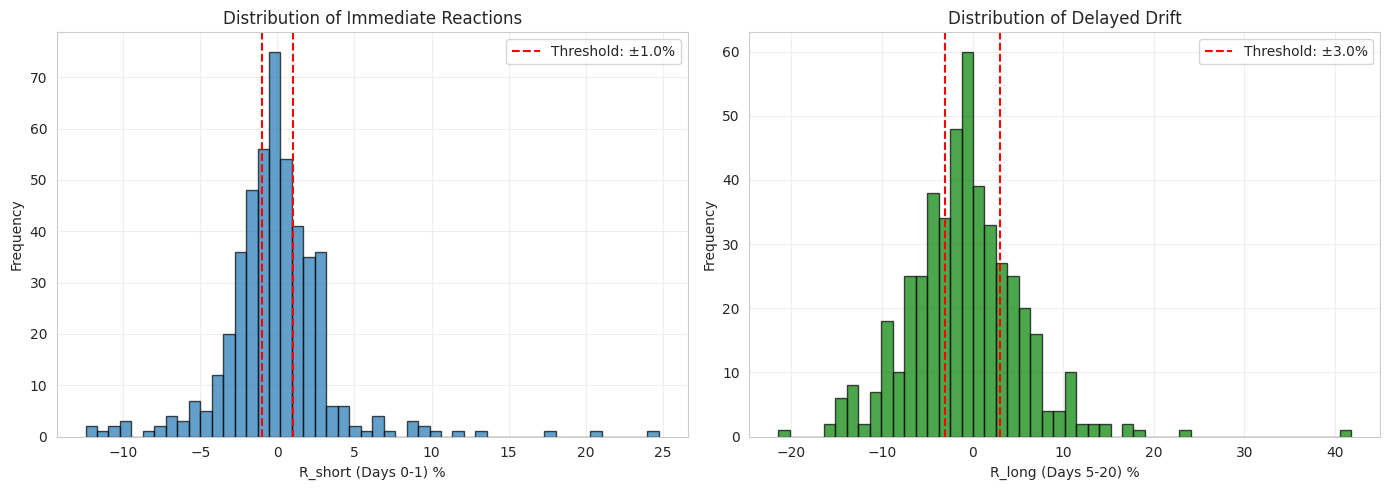

In [86]:
# Distribution of R_short vs R_long
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R_short distribution
axes[0].hist(results_df['R_short_0_1'] * 100, bins=50, alpha=0.7, edgecolor='black')
axes[0].axvline(SHORT_THRESHOLD * 100, color='red', linestyle='--', label=f'Threshold: ±{SHORT_THRESHOLD*100}%')
axes[0].axvline(-SHORT_THRESHOLD * 100, color='red', linestyle='--')
axes[0].set_xlabel('R_short (Days 0-1) %')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Immediate Reactions')
axes[0].legend()
axes[0].grid(alpha=0.3)

# R_long distribution
axes[1].hist(results_df['R_long_5_20'] * 100, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].axvline(LONG_THRESHOLD * 100, color='red', linestyle='--', label=f'Threshold: ±{LONG_THRESHOLD*100}%')
axes[1].axvline(-LONG_THRESHOLD * 100, color='red', linestyle='--')
axes[1].set_xlabel('R_long (Days 5-20) %')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Delayed Drift')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

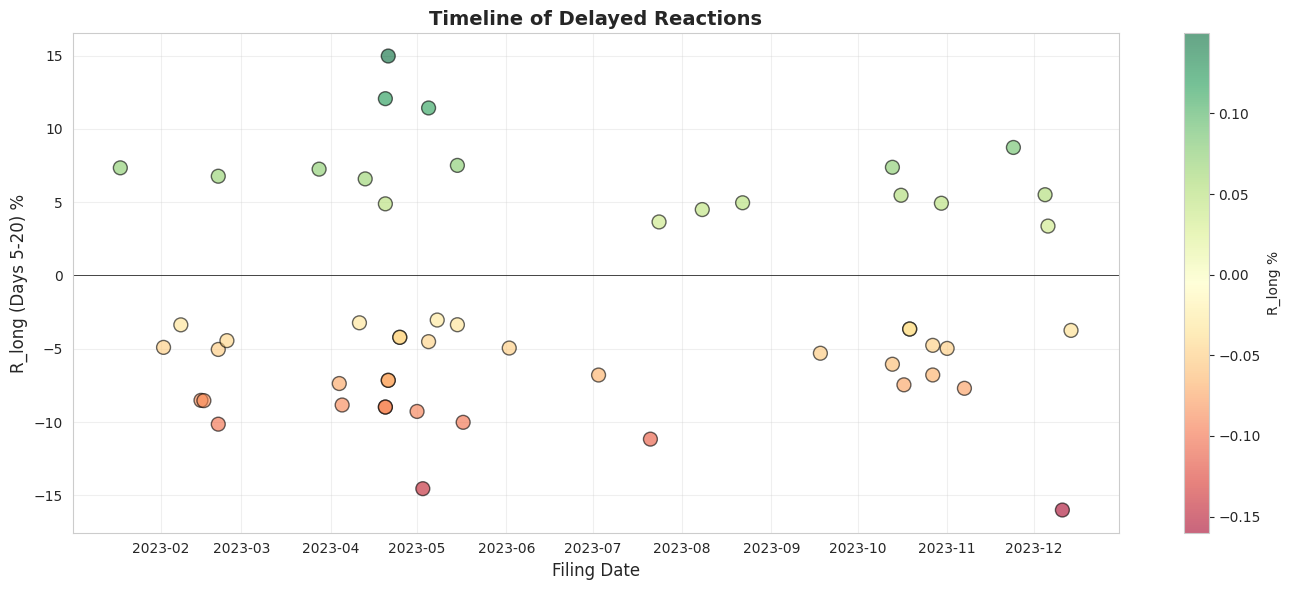

In [87]:
# Timeline of delayed reactions
if len(delayed) > 0:
    delayed_copy = delayed.copy()
    delayed_copy['filing_date'] = pd.to_datetime(delayed_copy['filing_date'])
    delayed_copy = delayed_copy.sort_values('filing_date')

    plt.figure(figsize=(14, 6))
    plt.scatter(delayed_copy['filing_date'],
               delayed_copy['R_long_5_20'] * 100,
               s=100, alpha=0.6, c=delayed_copy['R_long_5_20'],
               cmap='RdYlGn', edgecolors='black')
    plt.axhline(0, color='black', linestyle='-', linewidth=0.5)
    plt.xlabel('Filing Date', fontsize=12)
    plt.ylabel('R_long (Days 5-20) %', fontsize=12)
    plt.title('Timeline of Delayed Reactions', fontsize=14, weight='bold')
    plt.colorbar(label='R_long %')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Step 9: Save Results

In [88]:
import os

# Create output directory
OUTPUT_DIR = "delayed_reaction_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save all results
results_df.to_csv(f"{OUTPUT_DIR}/all_filings_analysis.csv", index=False)
print(f"✓ Saved all results → {OUTPUT_DIR}/all_filings_analysis.csv")

# Save delayed reactions only
if len(delayed) > 0:
    delayed.to_csv(f"{OUTPUT_DIR}/delayed_reactions_only.csv", index=False)
    print(f"✓ Saved delayed reactions → {OUTPUT_DIR}/delayed_reactions_only.csv")

# Save summary report
with open(f"{OUTPUT_DIR}/summary_report.txt", 'w') as f:
    f.write("DELAYED MARKET REACTION ANALYSIS\n")
    f.write("="*80 + "\n\n")
    f.write(f"Analysis Period: {START_DATE} to {END_DATE}\n")
    f.write(f"Benchmark: {BENCHMARK}\n")
    f.write(f"Short window: Days 0-1 (threshold: {SHORT_THRESHOLD*100}%)\n")
    f.write(f"Long window: Days 5-20 (threshold: {LONG_THRESHOLD*100}%)\n\n")

    f.write(f"Total filings analyzed: {len(results_df)}\n")
    f.write(f"Delayed reactions: {delayed_count} ({delayed_pct:.1f}%)\n\n")

    if len(delayed) > 0:
        f.write("Delayed Reaction Characteristics:\n")
        f.write(f"  Avg R_short: {delayed['R_short_0_1'].mean():+.5f} ({delayed['R_short_0_1'].mean()*100:+.2f}%)\n")
        f.write(f"  Avg R_long:  {delayed['R_long_5_20'].mean():+.5f} ({delayed['R_long_5_20'].mean()*100:+.2f}%)\n")
        f.write(f"  Max |R_long|: {delayed['R_long_5_20'].abs().max():+.5f} ({delayed['R_long_5_20'].abs().max()*100:+.2f}%)\n")

print(f"✓ Saved summary → {OUTPUT_DIR}/summary_report.txt")

print(f"\nAll outputs saved to: {OUTPUT_DIR}/")

✓ Saved all results → delayed_reaction_analysis/all_filings_analysis.csv
✓ Saved delayed reactions → delayed_reaction_analysis/delayed_reactions_only.csv
✓ Saved summary → delayed_reaction_analysis/summary_report.txt

All outputs saved to: delayed_reaction_analysis/
